<span style="color:#7589EC;">First Assignment
<br>
Name : Negar Fathi
<br>
Student ID : 400222069</span>

<span style="color:#7589EC;">1-	In this task you will carry out data analysis and build a regression a model for real state price prediction. The dataset for this task is available at https://www.kaggle.com/datasets/quantbruce/real-estate-price-prediction .</span>

<span style="color:#7589EC;">Load Data</span>

In [56]:
import pandas as pd
file_path = r"C:\Users\negar\OneDrive\Desktop\ML\Real estate.csv"
df = pd.read_csv(file_path, header=0) 
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


<span style="color:#7589EC;">a.	Explore and clean the dataset. Explain your steps and reasons behind your actions (such as choosing a specific imputation technique).</span>

In [57]:
df.shape

(414, 8)

In [58]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [59]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


<span style="color:#7589EC;">Our dataframe has 414 rows and 8 columns. We can see the name of the columns and some other useful data that like mean and std that has been calculated for each column. We can also see the type of each column. We can also see that there are no missing values in our data because there is no null value. We can double check with the code below:</span>

In [61]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

<span style="color:#7589EC;">To clean our code since there aren't any null values there isn't much to do. We can check if we have duplicate data and drop it. In my opinion the X1, X2, ... in the column names were a little distracting so I renamed the columns.</span>

In [62]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [63]:
df.rename(columns={'X1 transaction date': 'Transaction Date', 'X2 house age' : 'House Age', 'X3 distance to the nearest MRT station' : 'Nearest MRT Station',
                    'X4 number of convenience stores' : 'Number of Convenience Stores', 'X5 latitude' : 'Latitude',
                      'X6 longitude' : 'Longitude', 'Y house price of unit area' : 'Price Per Unit'}, inplace=True)
df.head()

,No,Transaction Date,House Age,Nearest MRT Station,Number of Convenience Stores,Latitude,Longitude,Price Per Unit
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


<span style="color:#7589EC;">b.	Visualize your data to gain better insights. Explain your findings. You can get some ideas from https://www.data-to-viz.com.</span>

<span style="color:#7589EC;">First we can plot the correlogram of this data to analyse the relationship between each pair of numeric variables of a matrix.</span>

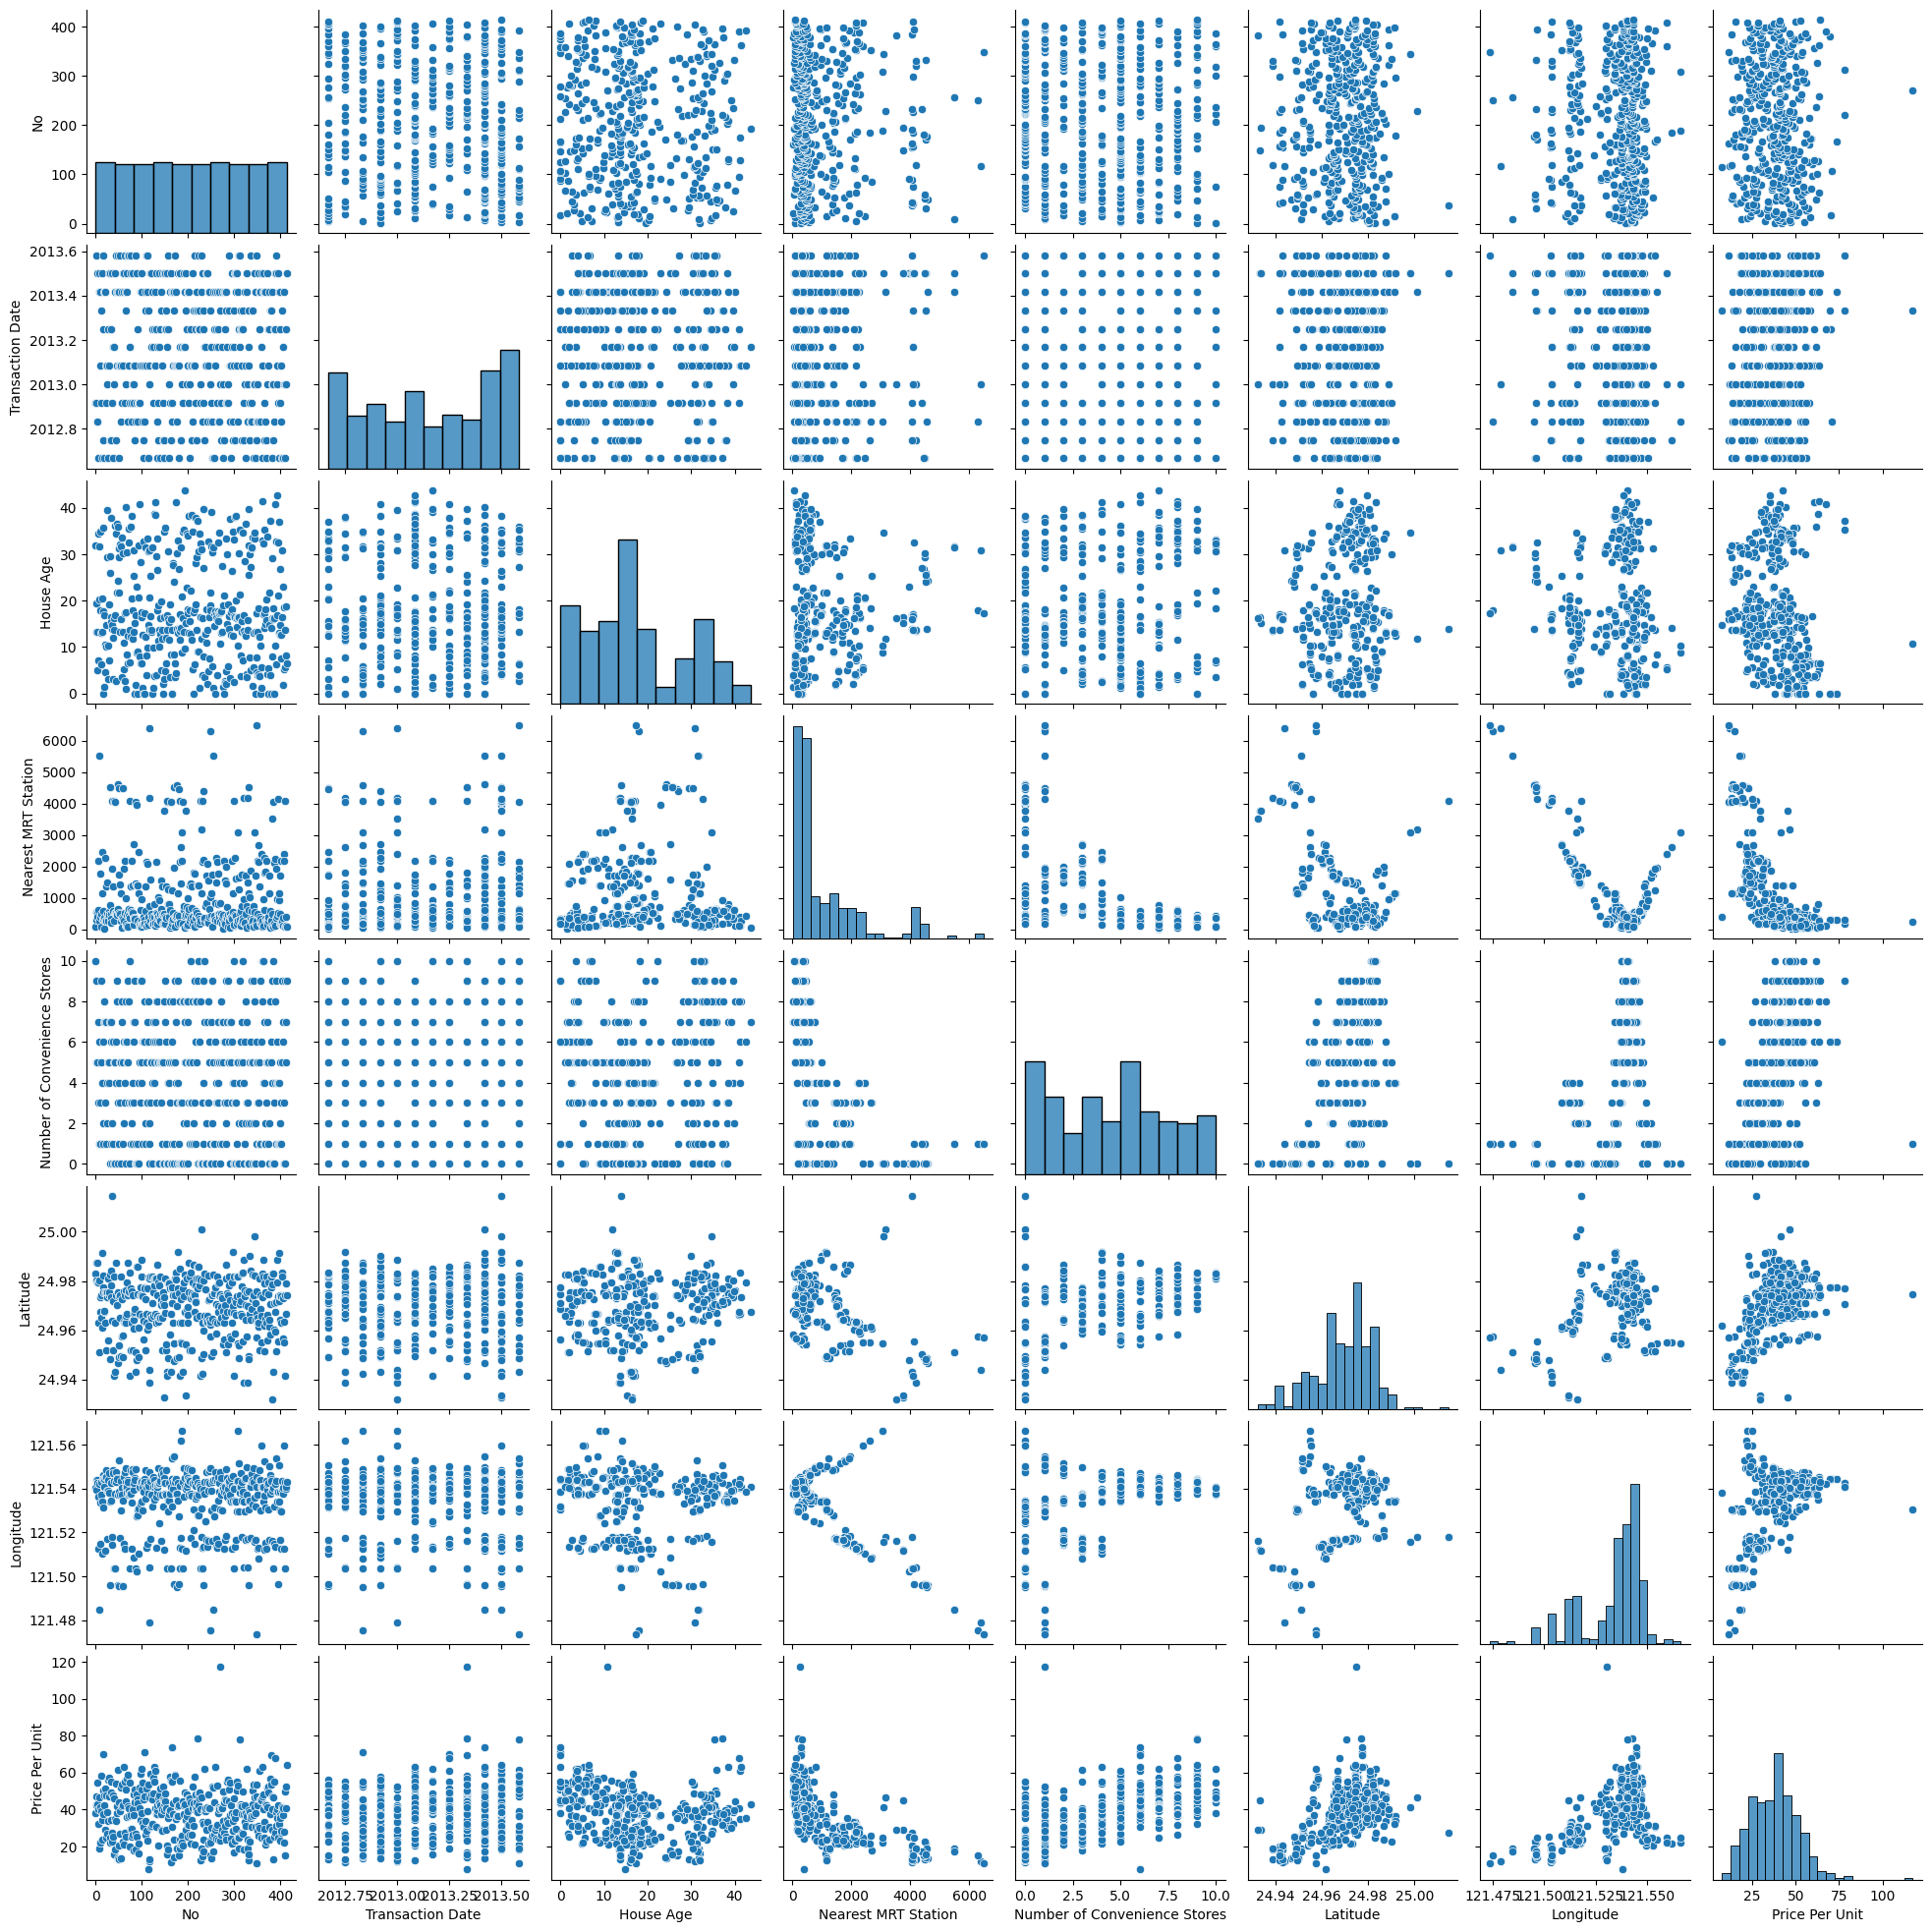

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df)
plt.show()

<span style="color:#7589EC;">According to this figure we can see there is a lot of concentration where the house age is around 15 and 35. And it seems like there is no correlation between the price and the age of the house:</span>

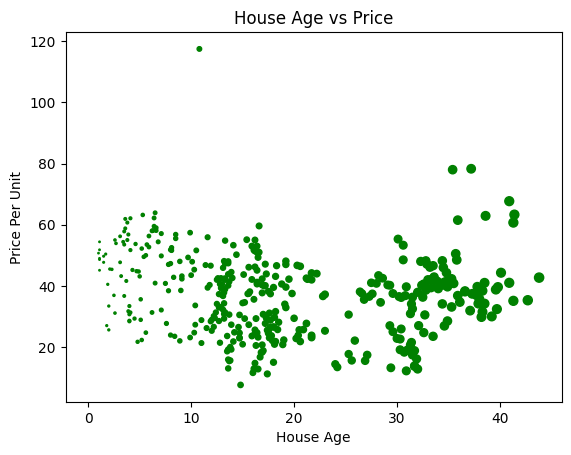

In [65]:
#plt.figure(figsize=(10, 10))
plt.scatter(df['House Age'], df['Price Per Unit'], c='g', s=df['House Age'])
plt.xlabel('House Age')
plt.ylabel('Price Per Unit')
plt.title('House Age vs Price')
plt.show()

<span style="color:#7589EC;">In this next figure we can see that if there is a MRT station near the house the price is higher:</span>

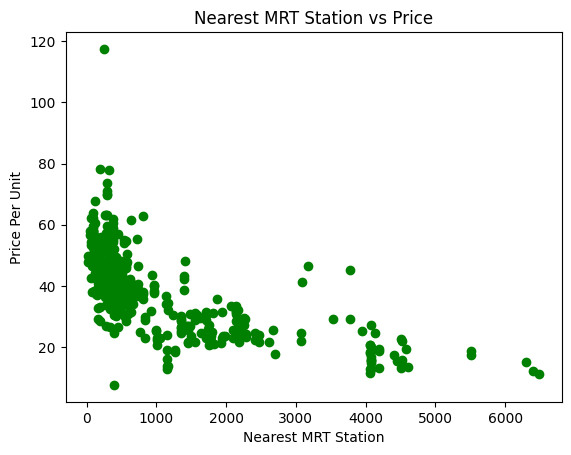

In [66]:
#plt.figure(figsize=(10, 10))
plt.scatter(df['Nearest MRT Station'], df['Price Per Unit'], c='g')
plt.xlabel('Nearest MRT Station')
plt.ylabel('Price Per Unit')
plt.title('Nearest MRT Station vs Price')
plt.show()

<span style="color:#7589EC;">Here we have a box plot for the house prices and we can see that we only have 2 outlier datas. And according to the figure we can guess the mean is a little less than 40.</span>

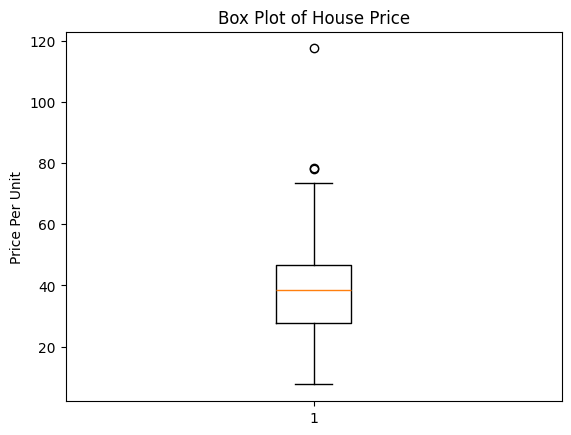

In [67]:
#plt.figure(figsize=(10, 10))
plt.boxplot(df['Price Per Unit'])
plt.ylabel('Price Per Unit')
plt.title('Box Plot of House Price')
plt.show()

<span style="color:#7589EC;">c.	Conduct the following tests. Include Null and Alternative hypothesis:</span>

<span style="color:#7589EC;">i.	Test if the average price per unit area of houses above the median age is significantly different from those below the median age. Use p-value method.
<br>
Here our Null hypothesis is : The average price per unit area of houses above the median age is not significantly different from those below the median age.
<br>
Our Alternative hypothesis is: The average price per unit area of houses above the median age is significantly different from those below the median age.</span>

In [68]:
from scipy import stats
median_age = df['House Age'].median()
above_median_age = df[df['House Age'] > median_age]
below_median_age = df[df['House Age'] <= median_age]
avg_price_above_median = above_median_age['Price Per Unit'].mean()
avg_price_below_median = below_median_age['Price Per Unit'].mean()
t_stat, p_value = stats.ttest_ind(above_median_age['Price Per Unit'], below_median_age['Price Per Unit'])
alpha = 0.05
if p_value < alpha:
    print("Null hypothesis is rejected.")
else:
    print("Alternative hypothesis is rejcted and Null hypothesis is accepted.")

Null hypothesis is rejected.


<span style="color:#7589EC;">Null hypothesis is rejected so that means the average price per unit area of houses above the median age is not significantly different from those below the median age.</span>

<span style="color:#7589EC;">ii. Investigate if the average price per unit area significantly differs by the number of convenience stores (categorized by "X4 number of convenience stores").
<br>
Null hypothesis: The average price per unit area does not significantly differ by the number of convenience stores.
<br>
Alternative hypothesis: The average price per unit area significantly differs by the number of convenience stores.
<br>
</span>

In [69]:
f_stat, p_value = stats.f_oneway(*[df['Price Per Unit'][df['Number of Convenience Stores'] == i] for i in df['Number of Convenience Stores'].unique()])

print("Results of one-way ANOVA:")
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("The null hypothesis is rejected and the alternative hypothesis is accepted.")
else:
    print("The null hypothesis is accepted.")

Results of one-way ANOVA:
F-statistic: 24.920758967875997
P-value: 1.178106724723706e-36
The null hypothesis is rejected and the alternative hypothesis is accepted.


<span style="color:#7589EC;"> Null hypothesis is rejected and that means that the average price per unit area significantly differs by the number of convenience stores.</span>

<span style="color:#7589EC;">iii. Choose two categorical variables and test if there's a significant association between them. (You may need to categorize some of the numerical variables.)
<br>
Null hypothesis: There isn't a significant association between these two categorical variables.
<br>
Alternative hypothesis: There is a significant association between these two categorical variables.</span>

In [70]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df['House Age'], df['Price Per Unit'])

chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print("Results of the chi-square test:")
print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print("There is a significant association between the two categorical variables.")
else:
    print("There is no significant association between the two categorical variables.")

Results of the chi-square test:
Chi-square statistic: 63921.08298319329
P-value: 0.023834606297105834
There is a significant association between the two categorical variables.


<span style="color:#7589EC;"> So the null hypothesis is rejected. </span>

<span style="color:#7589EC;">d.	Calculate the correlation between each variable and the target variable ("Y house price of unit area") to find which variable has the highest influence on the target.</span>

In [71]:
correlations = df.corr()['Price Per Unit'].sort_values(ascending=False)

print("Correlation coefficients between each variable and the target variable:")
print(correlations)

Correlation coefficients between each variable and the target variable:
Price Per Unit                  1.000000
Number of Convenience Stores    0.571005
Latitude                        0.546307
Longitude                       0.523287
Transaction Date                0.087491
No                             -0.028587
House Age                      -0.210567
Nearest MRT Station            -0.673613
Name: Price Per Unit, dtype: float64


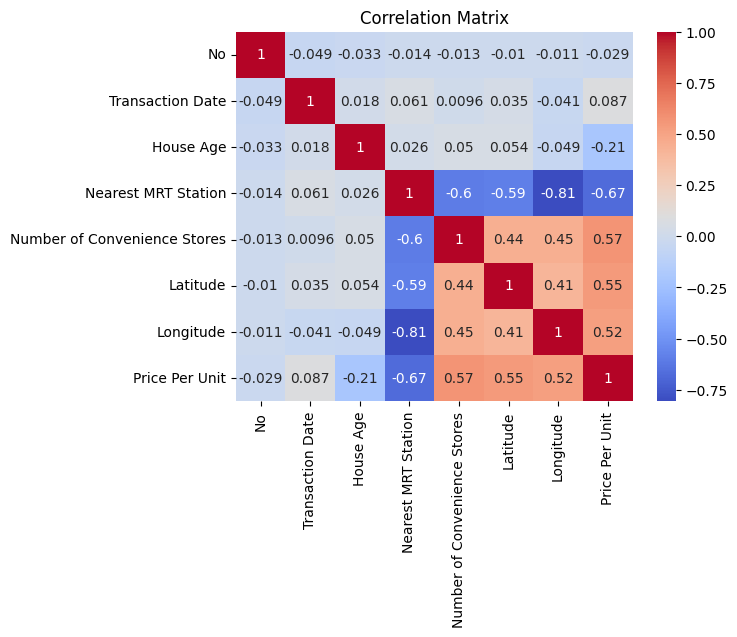

In [72]:
#plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

<span style="color:#7589EC;">Number of convenience stores has the highest positive coefficient so it has the highest positive influence on the price.
<br>
Nearest MRT station has the highest negative coefficient so it has the highest negative influence on the price. </spa>

<span style="color:#7589EC;">e. Use scikit learn to test-train split train simple linear regression model and extract the weights to confirm your findings from the last question.</span>

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Number of Convenience Stores', 'Latitude', 'Longitude', 'Transaction Date', 'House Age', 'Nearest MRT Station']]
y = df['Price Per Unit'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

coefficients = model.coef_
intercept = model.intercept_

print("Coefficients (Weights) of the Linear Regression Model:")
print(coefficients)
print("Intercept:", intercept)

Coefficients (Weights) of the Linear Regression Model:
[ 1.09142527e+00  2.29043054e+02 -2.94925908e+01  5.44074186e+00
 -2.70791490e-01 -4.75863892e-03]
Intercept: -13044.231917254105


<span style="color:#7589EC;">Here the highest negativee coefficient is nearest MRT station and so it has the same result as the previous section. </span>

<span style="color:#7589EC;">2-	In this we will analyze the life expectancy dataset provided by WHO. You can download it from this link: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who .</span>

<span style="color:#7589EC;">a.	Perform steps a and b similar to previous task.</span>

<span style="color:#7589EC;">Load Data</span>

In [74]:
file_path = r"C:\Users\negar\OneDrive\Desktop\ML\Life Expectancy Data.csv"
df = pd.read_csv(file_path, header=0) 
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [75]:
df.shape

(2938, 22)

In [76]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [78]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [79]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

<span style="color:#7589EC;">Since we have missing values we need to clean the dataset and to get rid of the missing values we can replace them with mean values of the data:</span>

In [80]:
from sklearn.impute import SimpleImputer
import numpy as np
imputer=SimpleImputer(missing_values=np.nan,strategy='mean',fill_value=None)
df['Life expectancy ']=imputer.fit_transform(df[['Life expectancy ']])
df['Adult Mortality']=imputer.fit_transform(df[['Adult Mortality']])
df['Alcohol']=imputer.fit_transform(df[['Alcohol']])
df['Hepatitis B']=imputer.fit_transform(df[['Hepatitis B']])
df[' BMI ']=imputer.fit_transform(df[[' BMI ']])
df['Polio']=imputer.fit_transform(df[['Polio']])
df['Total expenditure']=imputer.fit_transform(df[['Total expenditure']])
df['Diphtheria ']=imputer.fit_transform(df[['Diphtheria ']])
df['GDP']=imputer.fit_transform(df[['GDP']])
df['Population']=imputer.fit_transform(df[['Population']])
df[' thinness  1-19 years']=imputer.fit_transform(df[[' thinness  1-19 years']])
df[' thinness 5-9 years']=imputer.fit_transform(df[[' thinness 5-9 years']])
df['Income composition of resources']=imputer.fit_transform(df[['Income composition of resources']])
df['Schooling']=imputer.fit_transform(df[['Schooling']])

In [81]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

<span style="color:#7589EC;">Now we can remove duplicates and outliers. And also convert our string type columns to unique float values.</span>

In [82]:
from sklearn.preprocessing import OrdinalEncoder
ordinalEncoder1 = OrdinalEncoder()
ordinalEncoder2 = OrdinalEncoder()

df['Country'] = ordinalEncoder1.fit_transform(df['Country'].values.reshape(-1, 1))
df['Status'] = ordinalEncoder2.fit_transform(df['Status'].values.reshape(-1, 1))

df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0.0,2015,1.0,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,0.0,2014,1.0,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,0.0,2013,1.0,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,0.0,2012,1.0,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,0.0,2011,1.0,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [83]:
df.drop_duplicates(inplace=True)
df.shape

(2938, 22)

In [84]:
def outlier_removal(data):
    drop_outliers = np.array([])
    for col in data.columns:
        upper_bound = data[col].quantile(0.99)
        lower_bound = data[col].quantile(0.01)

        df = data[col]
        indices = df[(df < lower_bound) | (df > upper_bound)].index
        drop_outliers = np.append(drop_outliers, indices)
    return drop_outliers

In [85]:
cleaned_df = df.copy()
drop = outlier_removal(df)
dropped = np.unique(drop)
df.drop(dropped, inplace=True)
df.shape

(2385, 22)

<span style="color:#7589EC;">To further clean the data we have to rename some of the columns because they have extra spaces:</span>

In [86]:
df.rename(columns={" BMI ":"BMI","Life expectancy ":"Life_Expectancy","Adult Mortality":"Adult_Mortality",
                   "infant deaths":"Infant_Deaths","percentage expenditure":"Percentage_Exp","Hepatitis B":"HepatitisB",
                  "Measles ":"Measles"," BMI ":"BMI","under-five deaths ":"Under_Five_Deaths","Diphtheria ":"Diphtheria",
                  " HIV/AIDS":"HIV/AIDS"," thinness  1-19 years":"thinness_1to19_years"," thinness 5-9 years":"thinness_5to9_years","Income composition of resources":"Income_Comp_Of_Resources",
                   "Total expenditure":"Tot_Exp"},inplace=True)
df.head()

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Exp,HepatitisB,Measles,...,Polio,Tot_Exp,Diphtheria,HIV/AIDS,GDP,Population,thinness_1to19_years,thinness_5to9_years,Income_Comp_Of_Resources,Schooling
16,1.0,2015,1.0,77.8,74.0,0,4.60,364.975229,99.0,0,...,99.0,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
17,1.0,2014,1.0,77.5,8.0,0,4.51,428.749067,98.0,0,...,98.0,5.88,98.0,0.1,4575.763787,288914.0,1.2,1.3,0.761,14.2
18,1.0,2013,1.0,77.2,84.0,0,4.76,430.876979,99.0,0,...,99.0,5.66,99.0,0.1,4414.723140,289592.0,1.3,1.4,0.759,14.2
19,1.0,2012,1.0,76.9,86.0,0,5.14,412.443356,99.0,9,...,99.0,5.59,99.0,0.1,4247.614380,2941.0,1.3,1.4,0.752,14.2
20,1.0,2011,1.0,76.6,88.0,0,5.37,437.062100,99.0,28,...,99.0,5.71,99.0,0.1,4437.178680,295195.0,1.4,1.5,0.738,13.3


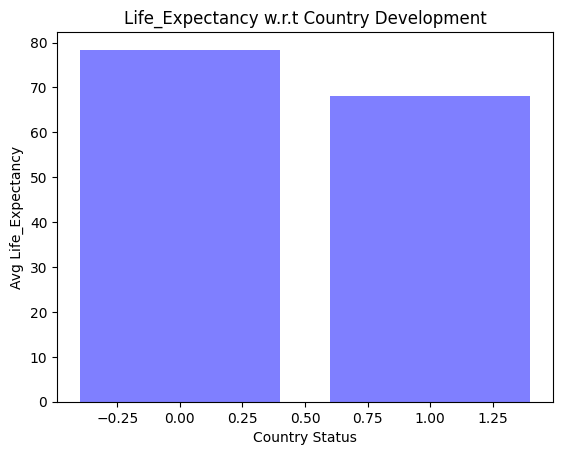

In [87]:
#plt.figure(figsize=(10,10))
plt.bar(df.groupby('Status')['Status'].count().index,df.groupby('Status')['Life_Expectancy'].mean(),color='blue',alpha=0.50)
plt.xlabel("Country Status")
plt.ylabel("Avg Life_Expectancy")
plt.title("Life_Expectancy w.r.t Country Development")
plt.show()

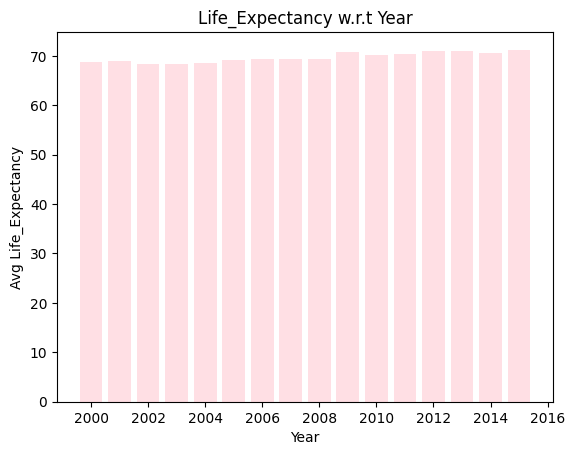

In [88]:
#plt.figure(figsize=(10,10))
plt.bar(df.groupby('Year')['Year'].count().index,df.groupby('Year')['Life_Expectancy'].mean(),color='pink',alpha=0.50)
plt.xlabel("Year")
plt.ylabel("Avg Life_Expectancy")
plt.title("Life_Expectancy w.r.t Year")
plt.show()

<span style="color:#7589EC;">There is a definite difference between developed countries and the rest, the life expectancy improves every year.</span>

[]

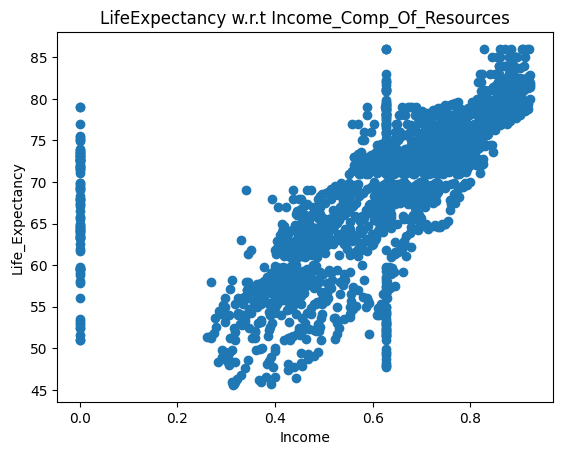

In [89]:
#plt.figure(figsize=(10,10))
plt.title("LifeExpectancy w.r.t Income_Comp_Of_Resources")
plt.xlabel("Income")
plt.ylabel("Life_Expectancy")
plt.scatter(df["Income_Comp_Of_Resources"], df["Life_Expectancy"])
plt.plot()

[]

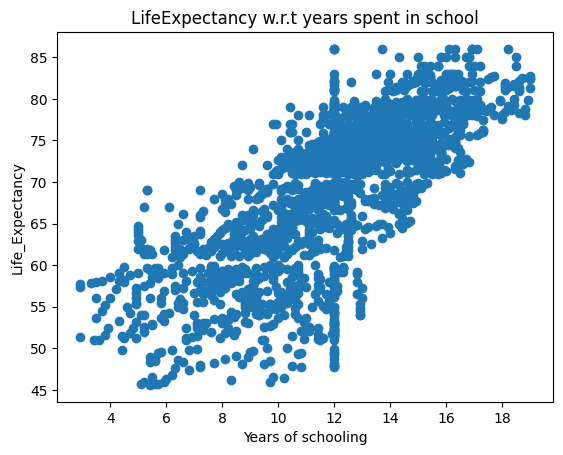

In [90]:
#plt.figure(figsize=(10,10))
plt.title("LifeExpectancy w.r.t years spent in school")
plt.xlabel("Years of schooling")
plt.ylabel("Life_Expectancy")
plt.scatter(df["Schooling"], df["Life_Expectancy"])
plt.plot()

[]

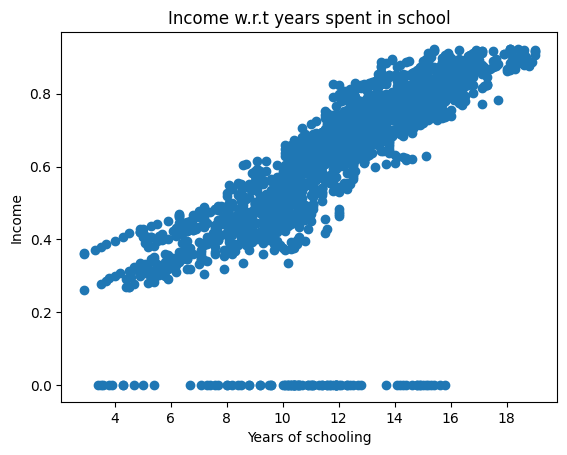

In [91]:
#plt.figure(figsize=(10,10))
plt.title("Income w.r.t years spent in school")
plt.xlabel("Years of schooling")
plt.ylabel("Income")
plt.scatter(df["Schooling"], df["Income_Comp_Of_Resources"])
plt.plot()

[]

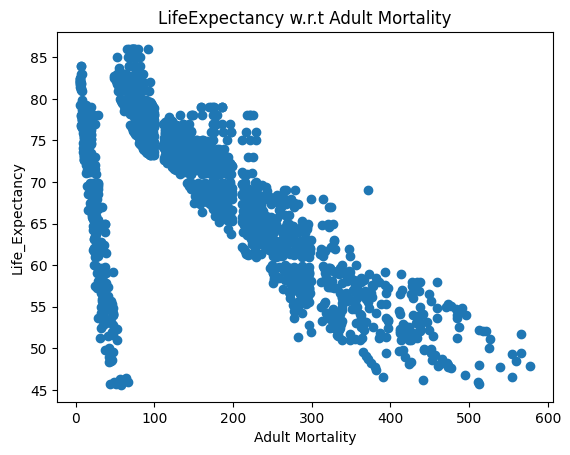

In [92]:
#plt.figure(figsize=(10,10))
plt.title("LifeExpectancy w.r.t Adult Mortality")
plt.xlabel("Adult Mortality")
plt.ylabel("Life_Expectancy")
plt.scatter(df["Adult_Mortality"], df["Life_Expectancy"])
plt.plot()

[]

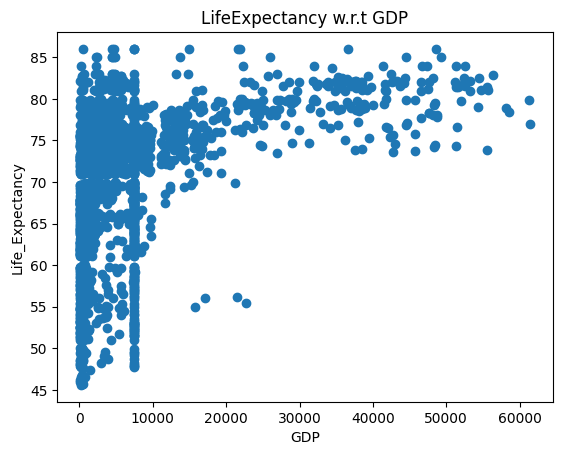

In [93]:
#plt.figure(figsize=(10,10))
plt.title("LifeExpectancy w.r.t GDP")
plt.xlabel("GDP")
plt.ylabel("Life_Expectancy")
plt.scatter(df["GDP"], df["Life_Expectancy"])
plt.plot()

[]

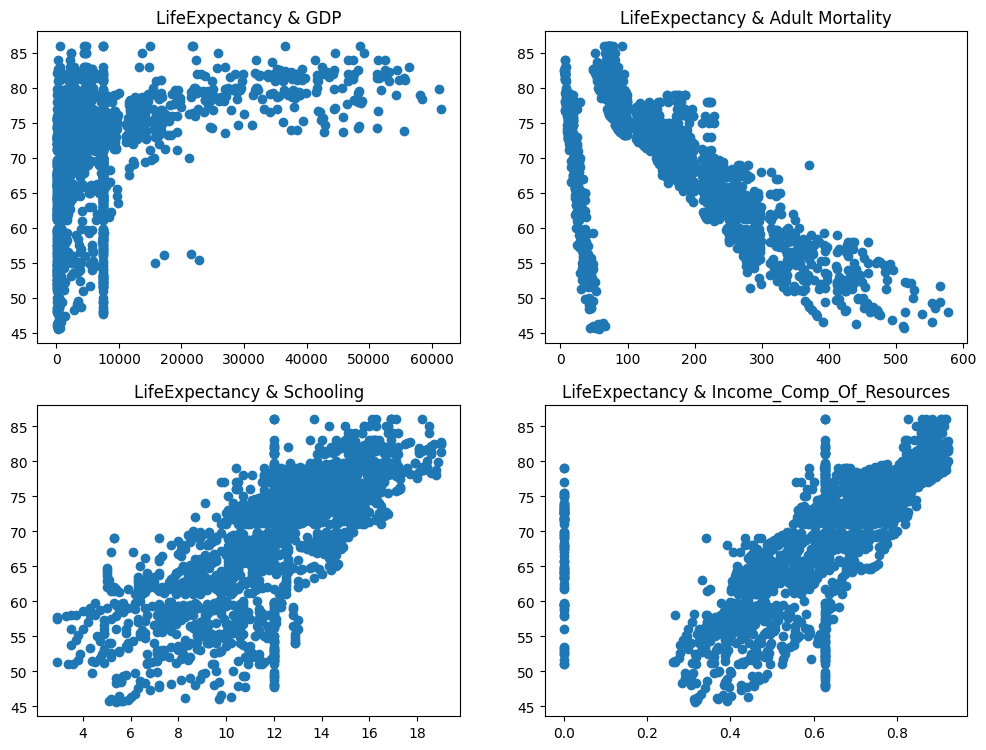

In [94]:
plt.figure(figsize=(12, 38))

plt.subplot(8,2,1)
plt.title("LifeExpectancy & GDP")
plt.scatter(df["GDP"], df["Life_Expectancy"])

plt.subplot(8,2,2)
plt.title("LifeExpectancy & Adult Mortality")
plt.scatter(df["Adult_Mortality"], df["Life_Expectancy"])

plt.subplot(8,2,3)
plt.title("LifeExpectancy & Schooling")
plt.scatter(df["Schooling"], df["Life_Expectancy"])

plt.subplot(8,2,4)
plt.title("LifeExpectancy & Income_Comp_Of_Resources")
plt.scatter(df["Income_Comp_Of_Resources"], df["Life_Expectancy"])
plt.plot()

<span style="color:#7589EC;">b.	Conduct the following tests. Include Null and Alternative hypothesis:</span>

<span style="color:#7589EC;">i. Investigate the relationship between Status (Developed vs. Developing) and the prevalence of a disease (for example, "Hepatitis B" vaccination rates).</span>

<span style="color:#7589EC;">Null Hypothesis: There is no significant difference in Hepatitis B vaccination rates between Developed and Developing countries.
<br>
Alternative Hypothesis: There is a significant difference in Hepatitis B vaccination rates between Developed and Developing countries.</span>

In [95]:
import scipy.stats as stats

developed_countries = df[df['Status'] == 'Developed']
developing_countries = df[df['Status'] == 'Developing']

mean_hepatitis_b_developed = developed_countries['HepatitisB'].mean()
mean_hepatitis_b_developing = developing_countries['HepatitisB'].mean()

t_statistic, p_value = stats.ttest_ind(developed_countries['HepatitisB'], developing_countries['HepatitisB'], nan_policy='omit')

print("Mean Hepatitis B Vaccination Rate in Developed Countries:", mean_hepatitis_b_developed)
print("Mean Hepatitis B Vaccination Rate in Developing Countries:", mean_hepatitis_b_developing)

alpha = 0.05
if p_value < alpha:
    print("Null hypothesis is rejected.")
else:
    print("Null hypothesis is accepted.")

print("T-Statistic:", t_statistic)
print("P-Value:", p_value)

Mean Hepatitis B Vaccination Rate in Developed Countries: nan
Mean Hepatitis B Vaccination Rate in Developing Countries: nan
Null hypothesis is accepted.
T-Statistic: nan
P-Value: nan


<span style="color:#7589EC;">ii. Compare the life expectancy (“Life Expectancy”) between Developed and Developing countries:</span>

<span style="color:#7589EC;">Null Hypothesis: There is no significant difference in life expectancy between Developed and Developing countries.
<br>
Alternative Hypothesis: There is a significant difference in life expectancy between Developed and Developing countries.</span>

In [96]:
developed_countries = df[df['Status'] == 'Developed']
developing_countries = df[df['Status'] == 'Developing']

mean_life_expectancy_developed = developed_countries['Life_Expectancy'].mean()
mean_life_expectancy_developing = developing_countries['Life_Expectancy'].mean()

t_statistic, p_value = stats.ttest_ind(developed_countries['Life_Expectancy'], developing_countries['Life_Expectancy'], nan_policy='omit')

print("Mean Life Expectancy in Developed Countries:", mean_life_expectancy_developed)
print("Mean Life Expectancy in Developing Countries:", mean_life_expectancy_developing)

alpha = 0.05
if p_value < alpha:
    print("Null hypothesis is rejected.")
else:
    print("Null hypothesis is accepted.")

print("\nT-Statistic:", t_statistic)
print("P-Value:", p_value)

Mean Life Expectancy in Developed Countries: nan
Mean Life Expectancy in Developing Countries: nan
Null hypothesis is accepted.

T-Statistic: nan
P-Value: nan


<span style="color:#7589EC;">iii. Compare the life expectancy ("Life expectancy") across multiple groups defined by the "Year" column.</span>

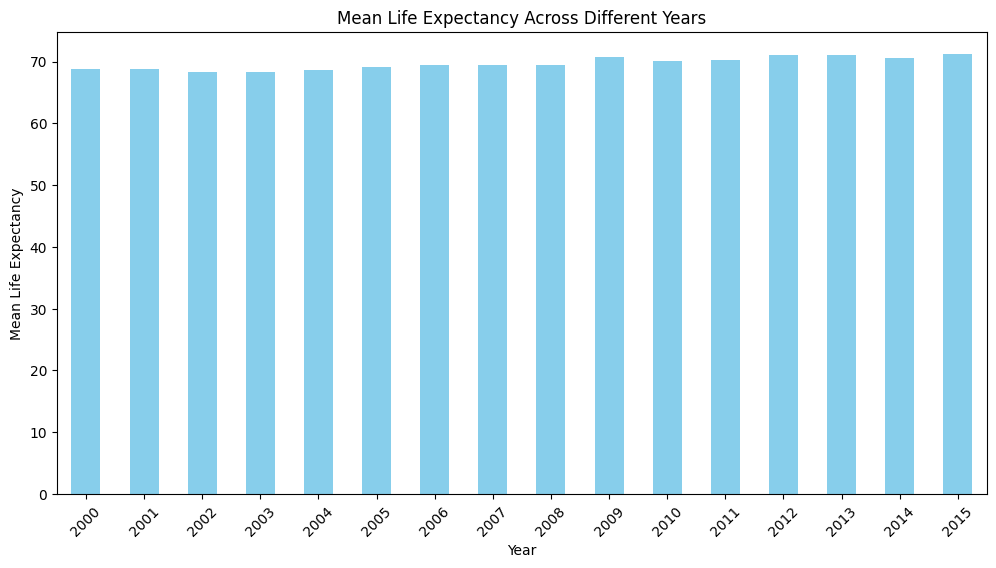

In [97]:
grouped_by_year = df.groupby('Year')

mean_life_expectancy_by_year = grouped_by_year['Life_Expectancy'].mean()

plt.figure(figsize=(12, 6))
mean_life_expectancy_by_year.plot(kind='bar', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Mean Life Expectancy')
plt.title('Mean Life Expectancy Across Different Years')
plt.xticks(rotation=45)
plt.show()

<span style="color:#7589EC;">iv. Design 2 more hypothesis tests to further explore the dataset.</span>

<span style="color:#7589EC;">a. Relationship between Alcohol consumption and Life Expectancy:
<br>
Null Hypothesis: There is no association between alcohol consumption and life expectancy.
<br>
Alternative Hypothesis: There is a significant association between alcohol consumption and life expectancy.</span>


In [98]:
low_alcohol_consumption = df[df['Alcohol'] < 4]
moderate_alcohol_consumption = df[(df['Alcohol'] >= 4) & (df['Alcohol'] < 8)]
high_alcohol_consumption = df[df['Alcohol'] >= 8]

mean_life_expectancy_low = low_alcohol_consumption['Life_Expectancy'].mean()
mean_life_expectancy_moderate = moderate_alcohol_consumption['Life_Expectancy'].mean()
mean_life_expectancy_high = high_alcohol_consumption['Life_Expectancy'].mean()

f_statistic, p_value = stats.f_oneway(low_alcohol_consumption['Life_Expectancy'], moderate_alcohol_consumption['Life_Expectancy'], high_alcohol_consumption['Life_Expectancy'])

print("Mean Life Expectancy for Low Alcohol Consumption:", mean_life_expectancy_low)
print("Mean Life Expectancy for Moderate Alcohol Consumption:", mean_life_expectancy_moderate)
print("Mean Life Expectancy for High Alcohol Consumption:", mean_life_expectancy_high)

alpha = 0.05
if p_value < alpha:
    print("Null hypothesis is rejected.")
else:
    print("Null hypothesis is accepted.")

# Display the F-statistic and p-value
print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

Mean Life Expectancy for Low Alcohol Consumption: 66.87536683513122
Mean Life Expectancy for Moderate Alcohol Consumption: 70.41444291609353
Mean Life Expectancy for High Alcohol Consumption: 75.35284986338797
Null hypothesis is rejected.
F-Statistic: 204.2142626328428
P-Value: 1.3918340163757568e-82


<span style="color:#7589EC;">b. Effect of Schooling on Adult Mortality:
<br>
Null Hypothesis: Schooling has no effect on adult mortality rates.
<br>
Alternative Hypothesis: Schooling has a significant effect on adult mortality rates.</span>

In [99]:
df.head()

,Country,Year,Status,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Percentage_Exp,HepatitisB,Measles,...,Polio,Tot_Exp,Diphtheria,HIV/AIDS,GDP,Population,thinness_1to19_years,thinness_5to9_years,Income_Comp_Of_Resources,Schooling
16,1.0,2015,1.0,77.8,74.0,0,4.60,364.975229,99.0,0,...,99.0,6.00,99.0,0.1,3954.227830,28873.0,1.2,1.3,0.762,14.2
17,1.0,2014,1.0,77.5,8.0,0,4.51,428.749067,98.0,0,...,98.0,5.88,98.0,0.1,4575.763787,288914.0,1.2,1.3,0.761,14.2
18,1.0,2013,1.0,77.2,84.0,0,4.76,430.876979,99.0,0,...,99.0,5.66,99.0,0.1,4414.723140,289592.0,1.3,1.4,0.759,14.2
19,1.0,2012,1.0,76.9,86.0,0,5.14,412.443356,99.0,9,...,99.0,5.59,99.0,0.1,4247.614380,2941.0,1.3,1.4,0.752,14.2
20,1.0,2011,1.0,76.6,88.0,0,5.37,437.062100,99.0,28,...,99.0,5.71,99.0,0.1,4437.178680,295195.0,1.4,1.5,0.738,13.3


In [100]:
low_schooling = df[df['Schooling'] < 8]
medium_schooling = df[(df['Schooling'] >= 8) & (df['Schooling'] < 12)]
high_schooling = df[df['Schooling'] >= 12]

adult_mortality_low = low_schooling['Adult_Mortality'].mean()
adult_mortality_medium = medium_schooling['Adult_Mortality'].mean()
adult_mortality_high = high_schooling['Adult_Mortality'].mean()

f_statistic, p_value = stats.f_oneway(low_schooling['Adult_Mortality'], medium_schooling['Adult_Mortality'], high_schooling['Adult_Mortality'])

print("Adult Mortality Rate for Low Schooling:", adult_mortality_low)
print("Adult Mortality Rate for Medium Schooling:", adult_mortality_medium)
print("Adult Mortality Rate for High Schooling:", adult_mortality_high)

alpha = 0.05
if p_value < alpha:
    print("Null hypothesis is rejected.")
else:
    print("Null hypothesis is accepted.")

print("F-Statistic:", f_statistic)
print("P-Value:", p_value)

Adult Mortality Rate for Low Schooling: 250.17703349282297
Adult Mortality Rate for Medium Schooling: 204.19815045915507
Adult Mortality Rate for High Schooling: 117.53200102693836
Null hypothesis is rejected.
F-Statistic: 289.1737711526774
P-Value: 3.702347943052622e-113


<span style="color:#7589EC;">c. Calculate the correlation between each variable and the target variable ("Life expectancy")</span>

In [103]:
features = df.drop('Life_Expectancy', axis=1)

correlations = features.corrwith(df['Life_Expectancy'])

correlations = correlations.sort_values(ascending=False)

print("Correlation between each variable and 'Life Expectancy':")
print(correlations)

Correlation between each variable and 'Life Expectancy':
Schooling                   0.750702
Income_Comp_Of_Resources    0.680859
BMI                         0.564431
Diphtheria                  0.447487
Polio                       0.444981
GDP                         0.431662
Alcohol                     0.392326
Percentage_Exp              0.387765
Tot_Exp                     0.219883
HepatitisB                  0.207712
Year                        0.108935
Population                  0.024039
Country                     0.010854
Measles                    -0.160629
Infant_Deaths              -0.427729
Status                     -0.443904
Under_Five_Deaths          -0.473171
thinness_5to9_years        -0.502243
thinness_1to19_years       -0.506830
HIV/AIDS                   -0.594984
Adult_Mortality            -0.705084
dtype: float64


<span style="color:#7589EC;">Schooling has the highest positive effect on life expectancy and adult mortality has the highest negatice effect on life expectancy.,</span>

<span style="color:#7589EC;">d. Test-train split your dataset such that there are no countries in both test and train splits. Now train two linear regression models, one including the column "Country" and another one with this column removed. How did it affect your model performance on test split? Which approach is correct?</span>

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train_countries, test_countries = train_test_split(df['Country'].unique(), test_size=0.2)
train_df = df[df['Country'].isin(train_countries)]
test_df = df[df['Country'].isin(test_countries)]

# Define features and target variable
X_train = train_df.drop(['Life_Expectancy'], axis=1)
X_test = test_df.drop(['Life_Expectancy'], axis=1)
y_train = train_df['Life_Expectancy']
y_test = test_df['Life_Expectancy']

model_with_country = LinearRegression()
model_with_country.fit(X_train, y_train)
y_pred_with_country = model_with_country.predict(X_test)
mse_with_country = mean_squared_error(y_test, y_pred_with_country)

X_train_without_country = X_train.drop(['Country'], axis=1)
X_test_without_country = X_test.drop(['Country'], axis=1)
model_without_country = LinearRegression()
model_without_country.fit(X_train_without_country, y_train)
y_pred_without_country = model_without_country.predict(X_test_without_country)
mse_without_country = mean_squared_error(y_test, y_pred_without_country)

print("Mean Squared Error with 'Country' column:", mse_with_country)
print("Mean Squared Error without 'Country' column:", mse_without_country)


Mean Squared Error with 'Country' column: 12.471316808381465
Mean Squared Error without 'Country' column: 12.607810821837257


<span style="color:#7589EC;"> The mean squared error when our regression model had the Country column is lower and that indicates better performance. 

<span style="color:#7589EC;">e.	Now test-train split the dataset randomly and perform the previous steps. How did the results change? Compare these results to part d. Which approach is correct?</span>

In [106]:
X = df.drop(['Life_Expectancy'], axis=1)
y = df['Life_Expectancy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_with_country_random = LinearRegression()
model_with_country_random.fit(X_train, y_train)
y_pred_with_country_random = model_with_country_random.predict(X_test)
mse_with_country_random = mean_squared_error(y_test, y_pred_with_country_random)

X_train_without_country_random = X_train.drop(['Country'], axis=1)
X_test_without_country_random = X_test.drop(['Country'], axis=1)
model_without_country_random = LinearRegression()
model_without_country_random.fit(X_train_without_country_random, y_train)
y_pred_without_country_random = model_without_country_random.predict(X_test_without_country_random)
mse_without_country_random = mean_squared_error(y_test, y_pred_without_country_random)

print("Mean Squared Error with 'Country' column (Random split):", mse_with_country_random)
print("Mean Squared Error without 'Country' column (Random split):", mse_without_country_random)


Mean Squared Error with 'Country' column (Random split): 12.111925208952302
Mean Squared Error without 'Country' column (Random split): 12.087575140619728


<span style="color:#7589EC;"> This time the mean squared error when our regression model didn't had  the Country column is lower and that indicates better performance.</span>

<span style="color:#7589EC;">f.	Train a simple linear regression model and another one with L1 regularization. Compare the model weights. Explain the results with the correlation values you calculated before.</span>

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso

X = df.drop(['Life_Expectancy'], axis=1)
y = df['Life_Expectancy']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_simple = LinearRegression()
model_simple.fit(X_scaled, y)
weights_simple = model_simple.coef_

model_lasso = Lasso(alpha=1.0)  
model_lasso.fit(X_scaled, y)
weights_lasso = model_lasso.coef_

print("Simple Linear Regression Model Weights:")
print(weights_simple)
print("\nLasso Regression Model Weights:")
print(weights_lasso)


Simple Linear Regression Model Weights:
[ 0.25802457 -0.04579113 -0.37912122 -2.14013452  5.54186746  0.12801246
  0.38209228 -0.12616768  0.0110076   0.56522154 -6.43083294  0.26578603
  0.24291913  0.56435285 -2.04175037  0.14891541  0.18445075 -0.26032956
 -0.03550567  1.11987971  2.16430432]

Lasso Regression Model Weights:
[ 0.          0.         -0.         -2.08661766 -0.          0.
  0.          0.         -0.          0.34116911 -0.34923894  0.
  0.          0.17593302 -1.66945343  0.          0.         -0.01263466
 -0.          0.99687373  2.81456084]


Correlation between each variable and 'Life Expectancy':
- Schooling: 0.750702
- Income_Comp_Of_Resources: 0.680859
- BMI: 0.564431
- Diphtheria: 0.447487
- Polio: 0.444981
- GDP: 0.431662
- Alcohol: 0.392326
- Percentage_Exp: 0.387765
- Tot_Exp: 0.219883
- HepatitisB: 0.207712
- Year: 0.108935
- Population: 0.024039
- Country: 0.010854
- Measles: -0.160629
- Infant_Deaths: -0.427729
- Status: -0.443904
- Under_Five_Deaths: -0.473171
- thinness_5to9_years: -0.502243
- thinness_1to19_years: -0.506830
- HIV/AIDS: -0.594984
- Adult_Mortality: -0.705084

Simple Linear Regression Model Weights:
- Schooling: 0.25802457
- Income_Comp_Of_Resources: -0.04579113
- BMI: -0.37912122
- Diphtheria: -2.14013452
- Polio: 5.54186746
- GDP: 0.12801246
- Alcohol: 0.38209228
- Percentage_Exp: -0.12616768
- Tot_Exp: 0.0110076
- HepatitisB: 0.56522154
- Year: -6.43083294
- Population: 0.26578603
- Country: 0.24291913
- Measles: 0.56435285
- Infant_Deaths: -2.04175037
- Status: 0.14891541
- Under_Five_Deaths: 0.18445075
- thinness_5to9_years: -0.26032956
- thinness_1to19_years: -0.03550567
- HIV/AIDS: 1.11987971
- Adult_Mortality: 2.16430432

Lasso Regression Model Weights:
- Schooling: 0
- Income_Comp_Of_Resources: 0
- BMI: -0
- Diphtheria: -2.08661766
- Polio: -0
- GDP: 0
- Alcohol: 0
- Percentage_Exp: 0
- Tot_Exp: -0
- HepatitisB: 0.34116911
- Year: -0.34923894
- Population: 0
- Country: 0
- Measles: 0.17593302
- Infant_Deaths: -1.66945343
- Status: 0
- Under_Five_Deaths: 0
- thinness_5to9_years: -0.01263466
- thinness_1to19_years: -0
- HIV/AIDS: 0.99687373
- Adult_Mortality: 2.81456084

Comparing the weights from the two models to the correlation values, we can observe the following:
- Lasso regression has effectively reduced the weights of some features to zero, performing feature selection.
- Features with higher correlations with 'Life Expectancy' tend to have higher weights in both models.
- Lasso regression has penalized some features with lower correlations by reducing their weights to zero or close to zero.
- The Lasso regression model may be more suitable for feature selection and regularization in this case, as it has effectively reduced the number of features in the model.
